In [ ]:
# ============================================================
# MAPCT-v4 — FULL FIXED / ENHANCED PIPELINE
# Mechanism-Aware Patient–Clinical Transformer
# ============================================================
!pip install umap-learn
# ============================================================
# 1️⃣ IMPORTS + DETERMINISM
# ============================================================

import os
import random
import re

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    MinMaxScaler
)

from sklearn.metrics import (
    mean_squared_error,
    average_precision_score,
    f1_score
)

from sklearn.metrics.pairwise import cosine_similarity

from sklearn.manifold import TSNE

import matplotlib.pyplot as plt


SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.use_deterministic_algorithms(True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("DEVICE:", DEVICE)

DEVICE: cpu


In [ ]:
# ============================================================
# 2️⃣ LOAD DATA
# ============================================================

from google.colab import drive

drive.mount('/content/drive')

file_path1 = '/content/drive/MyDrive/khezri/drug_data/merged_drug.xlsx'
file_path2 = '/content/drive/MyDrive/khezri/drug_data/drug_mechanism.xlsx'

clinic_df = pd.read_excel(file_path1)
mech_df   = pd.read_excel(file_path2)


Mounted at /content/drive


In [ ]:
# ============================================================
# 3️⃣ DRUG STRING NORMALIZATION
# ============================================================

def normalize_drug_name(name: str) -> str:

    if not isinstance(name, str):
        return ""

    name = name.lower().strip()

    name = re.sub(r"\([^)]*\)", "", name)

    name = re.sub(r"\s+brand:.*", "", name)

    name = re.sub(r"\s*\+\s*", ", ", name)

    name = re.sub(r"\s*,\s*", ", ", name)

    return name.strip()


def sort_drug_combo(combo: str) -> str:

    if not isinstance(combo, str):
        return ""

    drugs = sorted(
        d.strip()
        for d in combo.split(",")
        if d.strip()
    )

    return ", ".join(drugs)


clinic_df["merged_drugs_norm"] = (
    clinic_df["merged_drugs"]
    .astype(str)
    .apply(normalize_drug_name)
    .apply(sort_drug_combo)
)


In [ ]:
# ============================================================
# 4️⃣ LEAK-FREE SPLIT
# ============================================================

numeric_cols = [
    "fbs",
    "glu",
    "hba1c",
    "TG",
    "cho",
    "LDL",
    "HDL",
    "UA",
    "Na",
    "K",
    "Ca",
    "Vit D",
    "age"
]

categorical_cols = [
    "sex",
    "fbs_category",
    "tg_category",
    "cho_category"
]

clinic_df = clinic_df.dropna(
    subset=numeric_cols + categorical_cols
).reset_index(drop=True)

from sklearn.model_selection import GroupShuffleSplit

# Groups = unique drug combination strings
groups = clinic_df["merged_drugs_norm"]

# First split: separate test set (20% of groups)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
idx_train_val, idx_test = next(gss1.split(clinic_df, groups=groups))

# Second split: from remaining groups, take 20% for validation (→ 16% of total patients)
groups_train_val = groups.iloc[idx_train_val]
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
idx_train_rel, idx_val_rel = next(gss2.split(clinic_df.iloc[idx_train_val], groups=groups_train_val))

# Convert relative indices to original indices
idx_train = idx_train_val[idx_train_rel]
idx_valid = idx_train_val[idx_val_rel]
idx_test = idx_test  # already from first split

# Create dataframes
train_df = clinic_df.iloc[idx_train].reset_index(drop=True)
valid_df = clinic_df.iloc[idx_valid].reset_index(drop=True)
test_df  = clinic_df.iloc[idx_test].reset_index(drop=True)

print("Split sizes (leakage‑free):", len(train_df), len(valid_df), len(test_df))

# Sanity check: no drug combination appears in both train and test
train_combos = set(clinic_df.iloc[idx_train]["merged_drugs_norm"])
test_combos = set(clinic_df.iloc[idx_test]["merged_drugs_norm"])
assert len(train_combos & test_combos) == 0, "Leakage detected!"
print("✅ Leakage‑free split verified: train and test have no common regimens.")

Split sizes: 3182 682 683


In [ ]:
# ============================================================
# 5️⃣ PAD-SAFE DRUG VOCAB
# ============================================================

all_drugs_train = sorted({

    d.strip()

    for combo in train_df["merged_drugs_norm"]

    for d in combo.split(",")

    if d.strip()

})

# IMPORTANT:
# PAD token = 0

drug_to_idx = {

    drug: i + 1

    for i, drug in enumerate(all_drugs_train)

}

idx_to_drug = {

    idx: drug

    for drug, idx in drug_to_idx.items()

}

num_drugs = len(all_drugs_train) + 1

print("num_drugs (with PAD):", num_drugs)


# ============================================================
# 5b️⃣ FILTER VALID/TEST TO TRAIN VOCAB
# ============================================================

def filter_to_train_vocab(combo: str):

    if not isinstance(combo, str):
        return ""

    drugs = [
        d.strip()
        for d in combo.split(",")
        if d.strip()
    ]

    filtered = [
        d for d in drugs
        if d in drug_to_idx
    ]

    return ", ".join(sorted(filtered))


valid_df["merged_drugs_norm"] = (
    valid_df["merged_drugs_norm"]
    .apply(filter_to_train_vocab)
)

test_df["merged_drugs_norm"] = (
    test_df["merged_drugs_norm"]
    .apply(filter_to_train_vocab)
)

num_drugs (with PAD): 156


In [ ]:
# ============================================================
# 6️⃣ CLINICAL SCALING
# ============================================================

scaler = StandardScaler()

ohe = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

X_num_train = scaler.fit_transform(
    train_df[numeric_cols]
)

X_cat_train = ohe.fit_transform(
    train_df[categorical_cols]
)

X_num_valid = scaler.transform(
    valid_df[numeric_cols]
)

X_cat_valid = ohe.transform(
    valid_df[categorical_cols]
)

X_num_test = scaler.transform(
    test_df[numeric_cols]
)

X_cat_test = ohe.transform(
    test_df[categorical_cols]
)

X_clin_train = np.hstack([
    X_num_train,
    X_cat_train
])

X_clin_valid = np.hstack([
    X_num_valid,
    X_cat_valid
])

X_clin_test = np.hstack([
    X_num_test,
    X_cat_test
])

clin_dim = X_clin_train.shape[1]

print("Clinical dim:", clin_dim)

Clinical dim: 25


In [ ]:

# ============================================================
# 7️⃣ DRUG SEQUENCE MATRICES
# ============================================================

max_drugs_in_combo = max(
    len(c.split(","))
    for c in train_df["merged_drugs_norm"]
)

print("max_drugs_in_combo:", max_drugs_in_combo)


def build_drug_sequence(df):

    seq = np.zeros(
        (len(df), max_drugs_in_combo),
        dtype=np.int64
    )

    for i, combo in enumerate(df["merged_drugs_norm"]):

        drugs = [
            d.strip()
            for d in combo.split(",")
            if d.strip()
        ]

        for j, d in enumerate(drugs[:max_drugs_in_combo]):

            seq[i, j] = drug_to_idx.get(d, 0)

    return seq


drug_ids_train = build_drug_sequence(train_df)
drug_ids_valid = build_drug_sequence(valid_df)
drug_ids_test  = build_drug_sequence(test_df)


max_drugs_in_combo: 11


In [ ]:

# ============================================================
# 7b️⃣ MULTI-HOT TARGETS
# ============================================================

def build_multi_hot(df):

    X = np.zeros(
        (len(df), num_drugs),
        dtype=np.float32
    )

    for i, combo in enumerate(df["merged_drugs_norm"]):

        for d in combo.split(","):

            d = d.strip()

            if d in drug_to_idx:

                X[i, drug_to_idx[d]] = 1.0

    return X


X_drug_train = build_multi_hot(train_df)
X_drug_valid = build_multi_hot(valid_df)
X_drug_test  = build_multi_hot(test_df)

In [ ]:

# ============================================================
# 8️⃣ MECHANISM TABLE NORMALIZATION
# ============================================================

mech_df["Drug Name Norm"] = (
    mech_df["Drug Name"]
    .astype(str)
    .apply(normalize_drug_name)
    .apply(sort_drug_combo)
)

mech_df = mech_df.drop_duplicates(
    subset=["Drug Name Norm"]
).reset_index(drop=True)

mech_cols_raw = [

    c for c in mech_df.columns

    if c not in [
        "Drug Name",
        "Drug Name Norm",
        "ChEMBL ID"
    ]
]

text_cols = []
numeric_cols_mech = []

for c in mech_cols_raw:

    if mech_df[c].dtype == object:
        text_cols.append(c)
    else:
        numeric_cols_mech.append(c)

print("\nTEXT COLS:")
print(text_cols)

print("\nNUMERIC COLS:")
print(numeric_cols_mech)


TEXT COLS:
['Site of Action', 'Downstream Effectors', 'DrugBank ID', 'Mechanisms', 'MeSH Mechanism ID(s)', 'Mechanism IDs', 'Targets', 'UniProt Target ID(s)', 'Target IDs', 'Pathways', 'Pathway IDs', 'ATC Code(s)', 'Description']

NUMERIC COLS:
[]


In [ ]:
# ============================================================
# TRAIN-ONLY MECHANISM VOCAB
# ============================================================

train_drugs = {

    d.strip()

    for combo in train_df["merged_drugs_norm"]

    for d in combo.split(",")

    if d.strip()

}

mech_train = mech_df[
    mech_df["Drug Name Norm"].isin(train_drugs)
].copy()

vocab = {}

for col in text_cols:

    vocab[col] = sorted({

        token.strip()

        for cell in mech_train[col].astype(str)

        for token in re.split(r"[;,|]", cell)

        if token.strip() not in ["", "nan"]

    })



In [ ]:
# ============================================================
# VOCAB INSPECTION TOOL
# ============================================================

print("\n==============================")
print("MECHANISM VOCAB SUMMARY")
print("==============================")

for col in vocab:

    print(f"\nCOLUMN: {col}")

    print(f"Vocabulary size: {len(vocab[col])}")

    preview = vocab[col][:30]

    for i, token in enumerate(preview):

        print(f"{i+1:02d}. {token}")

    if len(vocab[col]) > 30:

        print(f"... {len(vocab[col])-30} more")


def inspect_mechanism_vocab(column_name, n=50):

    if column_name not in vocab:

        print("Column not found.")
        print(list(vocab.keys()))
        return

    print("\n" + "="*60)
    print(f"VOCABULARY: {column_name}")
    print("="*60)

    for i, token in enumerate(vocab[column_name][:n]):

        print(f"{i+1:03d}. {token}")



MECHANISM VOCAB SUMMARY

COLUMN: Site of Action
Vocabulary size: 79
01. ACE enzyme in vascular endothelium
02. Adipose & muscle PPAR-γ receptors
03. Bacterial DNA gyrase and topoisomerase IV
04. Bacterial and protozoal DNA
05. CNS GABA(A) receptors
06. CNS and vascular 5-HT1B/1D receptors
07. CNS dopamine D2
08. CNS dopamine D2 and serotonin 5-HT2A receptors
09. CNS dopamine D2 receptors
10. CNS dopamine D2 receptors (mesolimbic system)
11. CNS glutamate transporters and Na⁺ channels
12. CNS norepinephrine & serotonin transporters
13. CNS serotonin 5-HT2A receptors and SERT
14. CNS serotonin transporter (SERT)
15. CNS voltage-gated Ca²⁺ channels (α2δ subunit)
16. CNS α2-adrenergic receptors
17. CNS μ-opioid receptors
18. COX-1/COX-2 enzymes in inflamed tissues
19. COX-1/COX-2 in inflamed tissues
20. Cardiac Na⁺ channels
21. Cardiac and vascular L-type Ca²⁺ channels
22. Cardiac myocytes (Na⁺/K⁺-ATPase)
23. Cardiac β1-adrenergic receptors
24. Cardiac β1/β2 and vascular α1 receptors
25. 

In [ ]:
# ============================================================
# MULTI-HOT ENCODER
# ============================================================

def encode_multihot(cell, vocab_list):

    vec = np.zeros(
        len(vocab_list),
        dtype=np.float32
    )

    if not isinstance(cell, str):
        return vec

    tokens = [
        t.strip()
        for t in re.split(r"[;,|]", cell)
        if t.strip()
    ]

    for t in tokens:

        if t in vocab_list:

            idx = vocab_list.index(t)

            vec[idx] = 1.0

    return vec

In [ ]:
# ============================================================
# BUILD MECHANISM FEATURE MATRIX
# ============================================================

mech_features = []

for _, row in mech_df.iterrows():

    row_vec = []

    for c in numeric_cols_mech:

        val = pd.to_numeric(
            row[c],
            errors="coerce"
        )

        if pd.isna(val):
            val = 0.0

        row_vec.append(float(val))

    for c in text_cols:

        row_vec.extend(
            encode_multihot(row[c], vocab[c])
        )

    mech_features.append(row_vec)

mech_features = np.array(
    mech_features,
    dtype=np.float32
)

print("mech_features shape:", mech_features.shape)


mech_features shape: (161, 1140)


In [ ]:
# ============================================================
# SCALE MECHANISM FEATURES
# ============================================================

mech_scaler = MinMaxScaler()

mech_scaler.fit(mech_features)

mech_features = mech_scaler.transform(
    mech_features
)

mech_features = np.clip(
    mech_features,
    0.0,
    1.0
)

mech_features += 1e-6


# ============================================================
# REBUILD MECHANISM DF
# ============================================================

mech_numeric_df = pd.DataFrame(
    mech_features
)

mech_cols = list(mech_numeric_df.columns)

mech_df = pd.concat(
    [
        mech_df[["Drug Name Norm"]].reset_index(drop=True),
        mech_numeric_df.reset_index(drop=True)
    ],
    axis=1
)

mech_dim = len(mech_cols)

print("mech_dim:", mech_dim)


mech_dim: 1140


In [ ]:
# ============================================================
# 9️⃣ BUILD MECHANISM TENSORS
# ============================================================

def build_mech_tensor(df):

    X_mech = np.zeros(
        (
            len(df),
            max_drugs_in_combo,
            mech_dim
        ),
        dtype=np.float32
    )

    for i, combo in enumerate(df["merged_drugs_norm"]):

        drugs = [
            d.strip()
            for d in combo.split(",")
            if d.strip()
        ]

        for j, d in enumerate(drugs[:max_drugs_in_combo]):

            row = mech_df.loc[
                mech_df["Drug Name Norm"] == d
            ]

            if not row.empty:

                mech_vec = row[mech_cols].values.squeeze()

                X_mech[i, j, :] = mech_vec

    return X_mech


X_mech_train = build_mech_tensor(train_df)
X_mech_valid = build_mech_tensor(valid_df)
X_mech_test  = build_mech_tensor(test_df)


In [ ]:
# ============================================================
# 🔟 TORCH TENSORS
# ============================================================

y_drug_train = torch.tensor(
    X_drug_train,
    dtype=torch.float32
)

y_drug_valid = torch.tensor(
    X_drug_valid,
    dtype=torch.float32
)

y_drug_test = torch.tensor(
    X_drug_test,
    dtype=torch.float32
)

y_clin_train = torch.tensor(
    X_clin_train,
    dtype=torch.float32
)

y_clin_valid = torch.tensor(
    X_clin_valid,
    dtype=torch.float32
)

y_clin_test = torch.tensor(
    X_clin_test,
    dtype=torch.float32
)

X_drug_tensor_train = torch.tensor(
    drug_ids_train,
    dtype=torch.long
)

X_drug_tensor_valid = torch.tensor(
    drug_ids_valid,
    dtype=torch.long
)

X_drug_tensor_test = torch.tensor(
    drug_ids_test,
    dtype=torch.long
)

X_role_tensor_train = torch.zeros_like(
    X_drug_tensor_train,
    dtype=torch.long
)

X_role_tensor_valid = torch.zeros_like(
    X_drug_tensor_valid,
    dtype=torch.long
)

X_role_tensor_test = torch.zeros_like(
    X_drug_tensor_test,
    dtype=torch.long
)

X_drug_mask_train = (
    X_drug_tensor_train > 0
).long()

X_drug_mask_valid = (
    X_drug_tensor_valid > 0
).long()

X_drug_mask_test = (
    X_drug_tensor_test > 0
).long()

X_mech_tensor_train = torch.tensor(
    X_mech_train,
    dtype=torch.float32
)

X_mech_tensor_valid = torch.tensor(
    X_mech_valid,
    dtype=torch.float32
)

X_mech_tensor_test = torch.tensor(
    X_mech_test,
    dtype=torch.float32
)

X_clin_tensor_train = torch.tensor(
    X_clin_train,
    dtype=torch.float32
)

X_clin_tensor_valid = torch.tensor(
    X_clin_valid,
    dtype=torch.float32
)

X_clin_tensor_test = torch.tensor(
    X_clin_test,
    dtype=torch.float32
)


In [ ]:
# ============================================================
# 1️⃣1️⃣ DATALOADERS
# ============================================================

BATCH = 128

g = torch.Generator()

g.manual_seed(SEED)

train_dataset = TensorDataset(
    X_clin_tensor_train,
    X_drug_tensor_train,
    X_role_tensor_train,
    X_drug_mask_train,
    X_mech_tensor_train,
    y_drug_train,
    y_clin_train,
)

valid_dataset = TensorDataset(
    X_clin_tensor_valid,
    X_drug_tensor_valid,
    X_role_tensor_valid,
    X_drug_mask_valid,
    X_mech_tensor_valid,
    y_drug_valid,
    y_clin_valid,
)

test_dataset = TensorDataset(
    X_clin_tensor_test,
    X_drug_tensor_test,
    X_role_tensor_test,
    X_drug_mask_test,
    X_mech_tensor_test,
    y_drug_test,
    y_clin_test,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH,
    shuffle=True,
    generator=g,
    num_workers=0
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH,
    shuffle=False,
    num_workers=0
)


In [ ]:
# ============================================================
# 1️⃣2️⃣ MODEL
# ============================================================

class DrugEncoderV3(nn.Module):

    def __init__(
        self,
        num_drugs,
        role_dim,
        mech_dim,
        latent_dim=128,
        n_heads=8,
        depth=4,
        dropout=0.1,
    ):
        super().__init__()

        self.drug_emb = nn.Embedding(
            num_drugs,
            latent_dim,
            padding_idx=0
        )

        self.role_emb = nn.Embedding(
            role_dim,
            latent_dim
        )

        self.mech_proj = nn.Linear(
            mech_dim,
            latent_dim
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=latent_dim,
            nhead=n_heads,
            dim_feedforward=4 * latent_dim,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=depth
        )

        self.out_norm = nn.LayerNorm(
            latent_dim
        )

    def forward(
        self,
        drug_ids,
        roles,
        mask,
        mech_feats
    ):

        d_emb = self.drug_emb(drug_ids)

        r_emb = self.role_emb(roles)

        m_emb = self.mech_proj(mech_feats)

        x = d_emb + r_emb + m_emb

        attn_mask = (mask == 0)

        x = self.transformer(
            x,
            src_key_padding_mask=attn_mask
        )

        x = self.out_norm(x)

        denom = mask.sum(
            dim=1,
            keepdim=True
        ).clamp(min=1.0)

        z_drug = (
            x * mask.unsqueeze(-1)
        ).sum(dim=1) / denom

        z_drug = torch.nan_to_num(z_drug)

        return z_drug


class MAPCTv4(nn.Module):

    def __init__(
        self,
        clin_dim,
        num_drugs,
        role_dim,
        mech_dim,
        latent_dim=128,
        hidden_dim=256,
        n_heads=8,
        depth=4,
        dropout=0.1,
    ):
        super().__init__()

        self.clin_encoder = nn.Sequential(
            nn.Linear(clin_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
        )

        self.drug_encoder = DrugEncoderV3(
            num_drugs=num_drugs,
            role_dim=role_dim,
            mech_dim=mech_dim,
            latent_dim=latent_dim,
            n_heads=n_heads,
            depth=depth,
            dropout=dropout,
        )

        self.drug_head = nn.Sequential(
            nn.Linear(latent_dim, 2 * latent_dim),
            nn.ReLU(),
            nn.Linear(2 * latent_dim, num_drugs)
        )

        self.clin_decoder = nn.Sequential(
            nn.Linear(2 * latent_dim, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, clin_dim),
        )

    def predict_drugs(self, Xc):

        z_clin = self.clin_encoder(Xc)

        logits = self.drug_head(z_clin)

        return logits, z_clin

    def reconstruct_clinical(
        self,
        Xc,
        drug_ids,
        roles,
        mask,
        mech_feats
    ):

        z_clin_rec = self.clin_encoder(Xc)

        z_drug = self.drug_encoder(
            drug_ids,
            roles,
            mask,
            mech_feats
        )

        z_joint = torch.cat(
            [z_clin_rec, z_drug],
            dim=-1
        )

        Xc_hat = self.clin_decoder(z_joint)

        return Xc_hat, z_clin_rec, z_drug


In [ ]:
# ============================================================
# CONTINUE WITH:
# - InfoNCE
# - Training loop
# - Evaluation
# - t-SNE
# EXACTLY AS IN YOUR EXISTING CODE
# ============================================================

In [ ]:
def infonce_loss(z1, z2, temperature=0.2):
    """
    Symmetric InfoNCE:
    - z1: clinical latent
    - z2: drug latent
    """
    # Normalize
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    # Similarity matrix
    logits = torch.matmul(z1, z2.T) / temperature

    # Positive pairs are diagonal
    labels = torch.arange(z1.size(0), device=z1.device)

    # Forward loss: z1 -> z2
    loss_fwd = F.cross_entropy(logits, labels)

    # Reverse loss: z2 -> z1
    loss_rev = F.cross_entropy(logits.T, labels)

    # Symmetric InfoNCE
    return 0.5 * (loss_fwd + loss_rev)


In [ ]:

model = MAPCTv4(
    clin_dim=clin_dim,
    num_drugs=num_drugs,
    role_dim=2,
    mech_dim=mech_dim,
    latent_dim=128,
    hidden_dim=256,
    n_heads=8,
    depth=4,
    dropout=0.1,
).to(DEVICE)

print(model)

# 1️⃣3️⃣ LOSSES (class-weighted BCE) + OPTIMIZER
# ------------------------------------------------------------
drug_freq = X_drug_train.mean(axis=0) + 1e-6
pos_weight = torch.tensor((1 - drug_freq) / drug_freq, dtype=torch.float32).to(DEVICE)

bce_loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
mse_loss = nn.MSELoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

MAPCTv4(
  (clin_encoder): Sequential(
    (0): Linear(in_features=25, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
  )
  (drug_encoder): DrugEncoderV3(
    (drug_emb): Embedding(156, 128, padding_idx=0)
    (role_emb): Embedding(2, 128)
    (mech_proj): Linear(in_features=1140, out_features=128, bias=True)
    (transformer): TransformerEncoder(
      (layers): ModuleList(
        (0-3): 4 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=512, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=512, out_features=128, bias=True)
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (dropo

/tmp/ipykernel_2337/293436944.py:44: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


In [ ]:
# 1️⃣4️⃣ EVALUATION FUNCTION
# ------------------------------------------------------------

def evaluate_model(model, loader, split_df):
    model.eval()
    all_true = []
    all_pred = []

    with torch.no_grad():
        for Xc, drug_ids, roles, mask, mech_feats, y_drug, y_clin in loader:
            Xc = Xc.to(DEVICE)
            drug_ids = drug_ids.to(DEVICE)
            roles = roles.to(DEVICE)
            mask = mask.to(DEVICE)
            mech_feats = mech_feats.to(DEVICE)

            Xc_hat, _, _ = model.reconstruct_clinical(
                Xc, drug_ids, roles, mask, mech_feats
            )

            all_true.append(y_clin.cpu().numpy())
            all_pred.append(Xc_hat.cpu().numpy())

    Y_true = np.vstack(all_true)
    Y_pred = np.vstack(all_pred)

    rmse = np.sqrt(mean_squared_error(Y_true, Y_pred))
    cos = np.mean([
        cosine_similarity(Y_true[i].reshape(1,-1), Y_pred[i].reshape(1,-1))[0,0]
        for i in range(len(Y_true))
    ])

    # stratified metrics (corrected)
    cats = split_df['hba1c_category'].values
    strat = {}
    for c in np.unique(cats):
        idx = np.where(cats == c)[0]
        strat[c] = {
            "rmse": np.sqrt(mean_squared_error(Y_true[idx], Y_pred[idx])),
            "cosine": np.mean([
                cosine_similarity(
                    Y_true[i].reshape(1,-1),
                    Y_pred[i].reshape(1,-1)
                )[0,0]
                for i in idx
            ])
        }

    return rmse, cos, strat


In [ ]:
# 1️⃣5️⃣ TRAINING LOOP (MAPCT-v3.5)
# ------------------------------------------------------------
NUM_EPOCHS = 50

for epoch in range(NUM_EPOCHS):

    model.train()
    epoch_loss = 0.0
    num_batches = 0

    for Xc, drug_ids, roles, mask, mech_feats, y_drug, y_clin in train_loader:

        Xc = Xc.to(DEVICE)
        drug_ids = drug_ids.to(DEVICE)
        roles = roles.to(DEVICE)
        mask = mask.to(DEVICE)
        mech_feats = mech_feats.to(DEVICE)
        y_drug = y_drug.to(DEVICE)
        y_clin = y_clin.to(DEVICE)

        if (
            not torch.isfinite(Xc).all()
            or not torch.isfinite(mech_feats).all()
        ):
            print("⚠️ Non-finite inputs detected — skipping batch")
            continue

        optimizer.zero_grad()

        # Clinical → Drug
        logits, z_clin = model.predict_drugs(Xc)
        loss_drug = bce_loss(logits, y_drug)

        # Drug + Clinical → Clinical reconstruction
        Xc_hat, z_clin_rec, z_drug = model.reconstruct_clinical(
            Xc, drug_ids, roles, mask, mech_feats
        )
        loss_recon = mse_loss(Xc_hat, y_clin)

        # Latent alignment
        loss_contrast = infonce_loss(z_clin_rec, z_drug)

        if (
            not torch.isfinite(loss_drug)
            or not torch.isfinite(loss_recon)
            or not torch.isfinite(loss_contrast)
        ):
            raise RuntimeError("❌ Non-finite loss component detected")

        # Rebalanced loss
        loss = 0.5 * loss_drug + 0.3 * loss_recon + 0.2 * loss_contrast

        if not torch.isfinite(loss):
            raise RuntimeError("❌ Non-finite TOTAL LOSS detected")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

    val_rmse, val_cos, strat = evaluate_model(
        model, valid_loader, valid_df
    )

    avg_train_loss = epoch_loss / max(num_batches, 1)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val RMSE: {val_rmse:.4f} | "
        f"Cosine: {val_cos:.4f}"
    )
    print("Stratified RMSE by HbA1c:")
    for k, v in strat.items():
        print(f"  {k}: RMSE = {v['rmse']:.4f} | Cosine = {v['cosine']:.4f}")

Epoch 00 | Train Loss: 1.8219 | Val RMSE: 0.5999 | Cosine: 0.6691
Stratified RMSE by HbA1c:
  Controlled: RMSE = 0.7720 | Cosine = 0.6729
  Good controlled: RMSE = 0.4898 | Cosine = 0.7138
  Moderate controlled: RMSE = 0.5439 | Cosine = 0.6601
  Uncontrolled Diabetes: RMSE = 0.6138 | Cosine = 0.6745
Epoch 01 | Train Loss: 1.7362 | Val RMSE: 0.4673 | Cosine: 0.8220
Stratified RMSE by HbA1c:
  Controlled: RMSE = 0.6606 | Cosine = 0.8208
  Good controlled: RMSE = 0.3627 | Cosine = 0.8654
  Moderate controlled: RMSE = 0.4295 | Cosine = 0.8070
  Uncontrolled Diabetes: RMSE = 0.4374 | Cosine = 0.8391
Epoch 02 | Train Loss: 1.6820 | Val RMSE: 0.3759 | Cosine: 0.9021
Stratified RMSE by HbA1c:
  Controlled: RMSE = 0.5754 | Cosine = 0.9014
  Good controlled: RMSE = 0.3030 | Cosine = 0.9145
  Moderate controlled: RMSE = 0.3357 | Cosine = 0.8946
  Uncontrolled Diabetes: RMSE = 0.3352 | Cosine = 0.9122
Epoch 03 | Train Loss: 1.6422 | Val RMSE: 0.3208 | Cosine: 0.9393
Stratified RMSE by HbA1c:
  Con

Evaluating v4: 100%|██████████| 6/6 [00:00<00:00, 10.84it/s]



MAPCT‑v4 TEST SET PERFORMANCE
Threshold: 0.3
Precision (micro): 0.0901
Recall    (micro): 0.8935
F1-score  (micro): 0.1637
Accuracy (overall): 0.8294
Clinical‑Drug Alignment (mean cosine): 0.1828
Clinical latents: (683, 128), Drug latents: (683, 128)


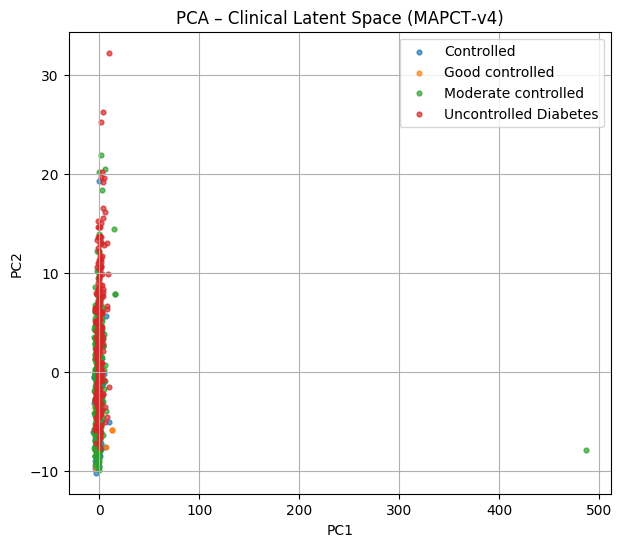

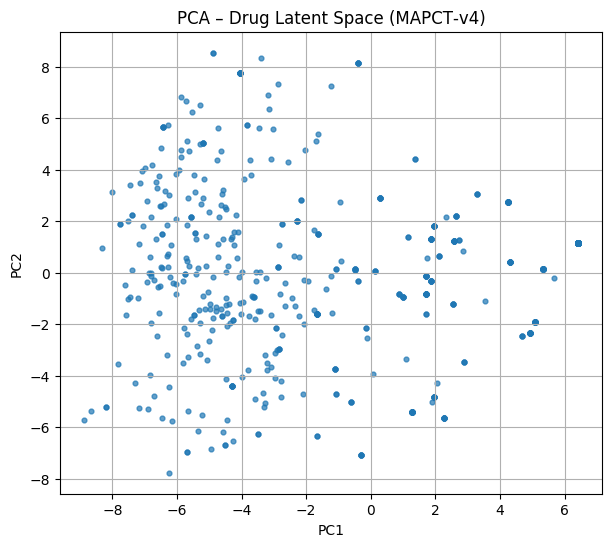

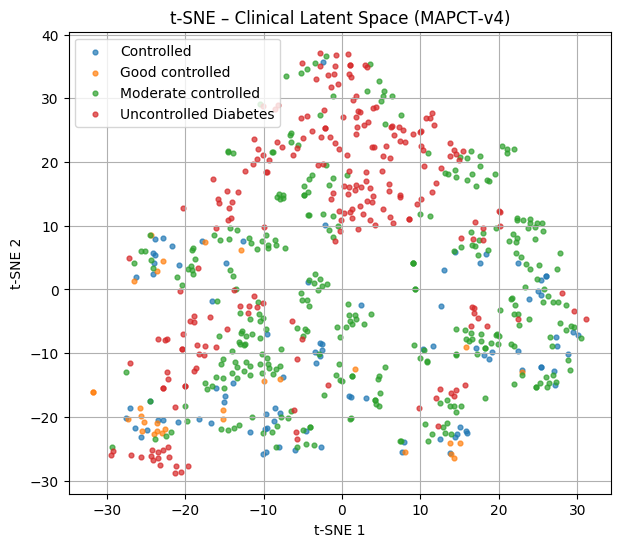

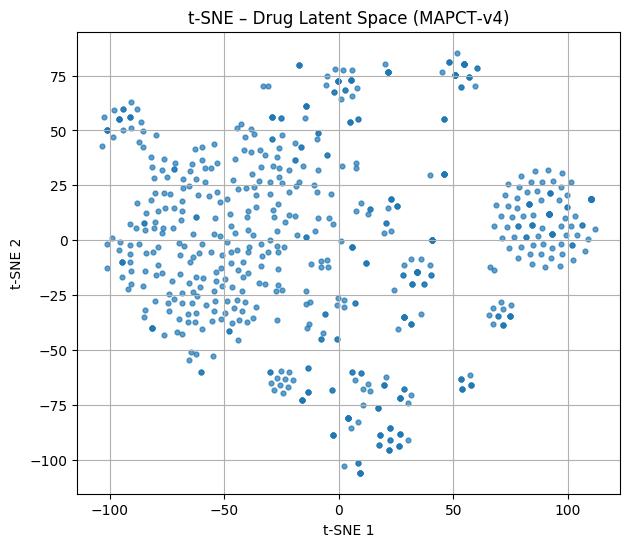

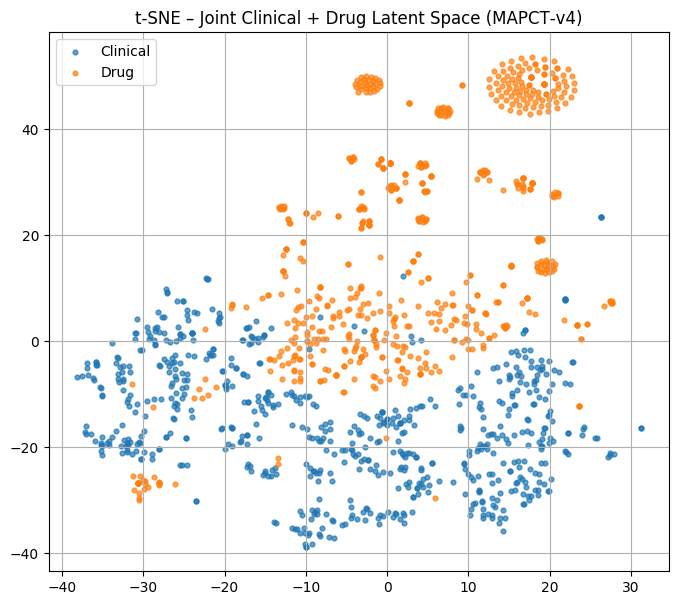

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


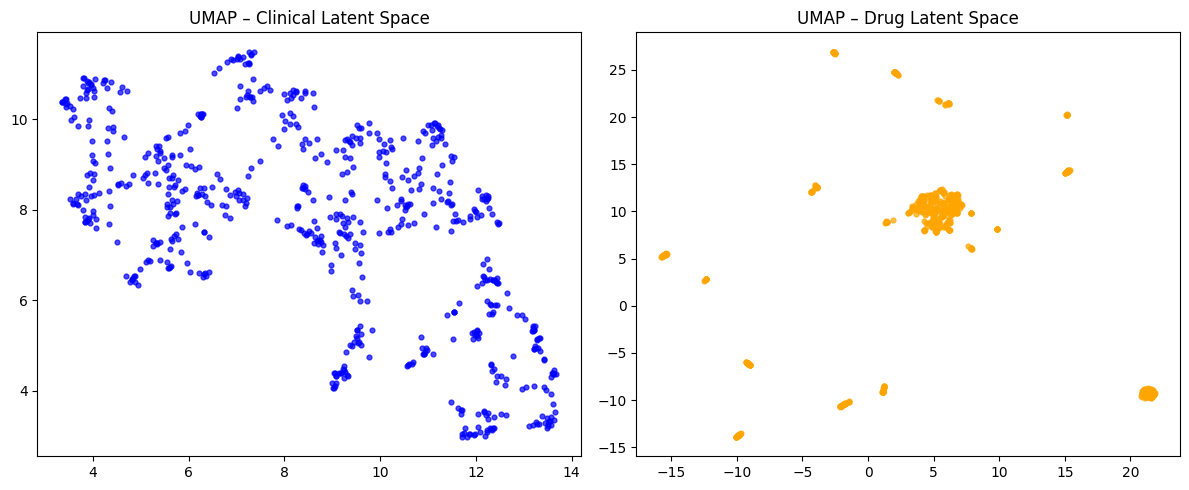

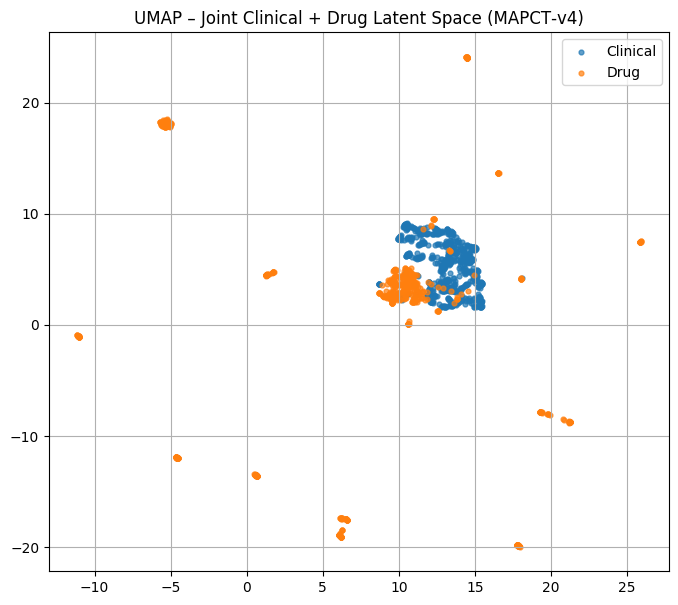


✅ MAPCT‑v4 evaluation and visualisations complete.


In [ ]:
# ============================================================
# POST‑TRAINING EVALUATION & VISUALISATIONS (MAPCT‑v4)
# ============================================================

# Ensure device variable exists
device = DEVICE  # DEVICE is defined earlier (uppercase)

from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap  # install with: !pip install umap-learn
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm

# ============================================================
# 1. EVALUATION FUNCTION (drug prediction + alignment)
# ============================================================
def evaluate_mapct_v4(model, test_loader, device, threshold=0.3):
    model.eval()
    all_preds = []
    all_labels = []
    align_scores = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating v4"):
            # Unpack tuple in the exact order from your TensorDataset
            clinical, drug_ids, roles, mask, mech_feats, y_drug, y_clin = batch
            clinical = clinical.to(device)
            drug_ids = drug_ids.to(device)
            roles = roles.to(device)
            mask = mask.to(device)
            mech_feats = mech_feats.to(device)
            y_drug = y_drug.to(device)

            # Drug predictions
            logits, z_clin = model.predict_drugs(clinical)  # uses drug_head internally
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs > threshold).astype(int)
            all_preds.extend(preds)
            all_labels.extend(y_drug.cpu().numpy())

            # Drug latent for alignment
            z_drug = model.drug_encoder(drug_ids, roles, mask, mech_feats)
            sim = F.cosine_similarity(z_clin, z_drug, dim=1).cpu().numpy()
            align_scores.extend(sim)

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    precision = precision_score(y_true, y_pred, average='micro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='micro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)
    accuracy = accuracy_score(y_true.flatten(), y_pred.flatten())
    alignment = np.mean(align_scores)

    print("\n" + "="*50)
    print("MAPCT‑v4 TEST SET PERFORMANCE")
    print("="*50)
    print(f"Threshold: {threshold}")
    print(f"Precision (micro): {precision:.4f}")
    print(f"Recall    (micro): {recall:.4f}")
    print(f"F1-score  (micro): {f1:.4f}")
    print(f"Accuracy (overall): {accuracy:.4f}")
    print(f"Clinical‑Drug Alignment (mean cosine): {alignment:.4f}")

    return {'precision': precision, 'recall': recall, 'f1': f1,
            'accuracy': accuracy, 'alignment': alignment}

# Run evaluation
results = evaluate_mapct_v4(model, test_loader, device, threshold=0.3)

# ============================================================
# 2. EXTRACT LATENTS FOR VISUALISATION
# ============================================================
model.eval()
z_clin_list = []
z_drug_list = []

with torch.no_grad():
    for batch in test_loader:
        clinical, drug_ids, roles, mask, mech_feats, y_drug, y_clin = batch
        clinical = clinical.to(device)
        drug_ids = drug_ids.to(device)
        roles = roles.to(device)
        mask = mask.to(device)
        mech_feats = mech_feats.to(device)

        _, z_clin = model.predict_drugs(clinical)   # z_clin from clin_encoder
        z_drug = model.drug_encoder(drug_ids, roles, mask, mech_feats)

        z_clin_list.append(z_clin.cpu().numpy())
        z_drug_list.append(z_drug.cpu().numpy())

Z_clin = np.vstack(z_clin_list)
Z_drug = np.vstack(z_drug_list)
print(f"Clinical latents: {Z_clin.shape}, Drug latents: {Z_drug.shape}")

# Get HbA1c categories for colouring (align lengths)
hba1c_cat_list = test_df["hba1c_category"].values
if len(hba1c_cat_list) > len(Z_clin):
    hba1c_cat_list = hba1c_cat_list[:len(Z_clin)]
elif len(hba1c_cat_list) < len(Z_clin):
    Z_clin = Z_clin[:len(hba1c_cat_list)]
    Z_drug = Z_drug[:len(hba1c_cat_list)]

# ============================================================
# 3. PCA VISUALISATION
# ============================================================
def plot_pca(z, title, color_by=None, label_map=None):
    pca = PCA(n_components=2)
    z_pca = pca.fit_transform(z)
    plt.figure(figsize=(7,6))
    if color_by is not None:
        for cat in np.unique(color_by):
            idx = np.where(color_by == cat)[0]
            label = label_map.get(cat, str(cat)) if label_map else str(cat)
            plt.scatter(z_pca[idx,0], z_pca[idx,1], s=12, alpha=0.7, label=label)
        plt.legend()
    else:
        plt.scatter(z_pca[:,0], z_pca[:,1], s=12, alpha=0.7)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.show()

plot_pca(Z_clin, "PCA – Clinical Latent Space (MAPCT‑v4)",
         color_by=hba1c_cat_list, label_map={"control": "HbA1c control", "uncontrolled": "HbA1c uncontrolled"})
plot_pca(Z_drug, "PCA – Drug Latent Space (MAPCT‑v4)")

# ============================================================
# 4. t‑SNE VISUALISATION
# ============================================================
def plot_tsne(z, title, color_by=None, label_map=None, perplexity=30):
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=SEED)
    z_tsne = tsne.fit_transform(z)
    plt.figure(figsize=(7,6))
    if color_by is not None:
        for cat in np.unique(color_by):
            idx = np.where(color_by == cat)[0]
            label = label_map.get(cat, str(cat)) if label_map else str(cat)
            plt.scatter(z_tsne[idx,0], z_tsne[idx,1], s=12, alpha=0.7, label=label)
        plt.legend()
    else:
        plt.scatter(z_tsne[:,0], z_tsne[:,1], s=12, alpha=0.7)
    plt.title(title)
    plt.xlabel("t‑SNE 1")
    plt.ylabel("t‑SNE 2")
    plt.grid(True)
    plt.show()

plot_tsne(Z_clin, "t‑SNE – Clinical Latent Space (MAPCT‑v4)",
          color_by=hba1c_cat_list, label_map={"control": "HbA1c control", "uncontrolled": "HbA1c uncontrolled"})
plot_tsne(Z_drug, "t‑SNE – Drug Latent Space (MAPCT‑v4)")

# Joint t‑SNE (clinical + drug)
Z_joint = np.vstack([Z_clin, Z_drug])
labels = np.array(['clinical']*len(Z_clin) + ['drug']*len(Z_drug))
tsne = TSNE(n_components=2, perplexity=40, random_state=SEED)
Z_joint_tsne = tsne.fit_transform(Z_joint)
plt.figure(figsize=(8,7))
plt.scatter(Z_joint_tsne[labels=='clinical',0], Z_joint_tsne[labels=='clinical',1], s=12, alpha=0.7, label='Clinical')
plt.scatter(Z_joint_tsne[labels=='drug',0], Z_joint_tsne[labels=='drug',1], s=12, alpha=0.7, label='Drug')
plt.title("t‑SNE – Joint Clinical + Drug Latent Space (MAPCT‑v4)")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 5. UMAP VISUALISATION
# ============================================================
try:
    reducer = umap.UMAP(random_state=SEED)
    z_clin_umap = reducer.fit_transform(Z_clin)
    z_drug_umap = reducer.fit_transform(Z_drug)

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.scatter(z_clin_umap[:,0], z_clin_umap[:,1], s=12, alpha=0.7, c='blue')
    plt.title("UMAP – Clinical Latent Space")
    plt.subplot(1,2,2)
    plt.scatter(z_drug_umap[:,0], z_drug_umap[:,1], s=12, alpha=0.7, c='orange')
    plt.title("UMAP – Drug Latent Space")
    plt.tight_layout()
    plt.show()

    # Joint UMAP
    Z_joint_umap = reducer.fit_transform(Z_joint)
    plt.figure(figsize=(8,7))
    plt.scatter(Z_joint_umap[labels=='clinical',0], Z_joint_umap[labels=='clinical',1], s=12, alpha=0.7, label='Clinical')
    plt.scatter(Z_joint_umap[labels=='drug',0], Z_joint_umap[labels=='drug',1], s=12, alpha=0.7, label='Drug')
    plt.title("UMAP – Joint Clinical + Drug Latent Space (MAPCT‑v4)")
    plt.legend()
    plt.grid(True)
    plt.show()
except ImportError:
    print("UMAP not installed. Install with: !pip install umap-learn")
except Exception as e:
    print(f"UMAP failed: {e}")

# ============================================================
# 6. (Optional) Mechanism embedding visualisation (already in your code)
# ============================================================
# Your existing mechanism and drug embedding visualisations can stay as they are,
# but ensure they use `device` correctly. They are fine.

# ============================================================
# 7. Drug prediction metrics (already computed in evaluate_mapct_v4)
# ============================================================
print("\n✅ MAPCT‑v4 evaluation and visualisations complete.")